In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 필요 라이브러리 import

In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import sys
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split # 데이터 분리
from tensorflow.keras.utils import to_categorical
import openpyxl

# 이진분류분석과 분류분석
이진분류
```
1. 데이터 셋 생성 & 전처리
    엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리 -> X,y분리 -> X 변수 스케일조정
2. 모델 생성 
    * model.summary() 주의
3. 모델 학습과정 설정 => input : 13, final_output : 1
    Input, Dense, Dropout?
4. 모델 학습
5. 모델 학습 결과 확인
    1) 학습 과정 그래프화
    2) evaluate => loss, accuracy 체크
    3) 교차표 그리기
6. 모델 저장 및 사용
```

분류분석
```
1. 데이터 셋 생성 & 전처리
    엑셀 -> 데이터프레임 -> ? 처리(df.replace('?',np.nan) -> 결측치 처리 -> X,y분리 -> X 변수 스케일조정
    -> y변수들 원핫인코딩(to_categorical 함수 이용)
2. 모델 생성 
    * model.summary() 주의
3. 모델 학습과정 설정 => input : 13, final_output : 2
    Input, Dense, Dropout?
4. 모델 학습
5. 모델 학습 결과 확인
    1) 학습 과정 그래프화
    2) evaluate => loss, accuracy 체크
    3) 교차표 그리기
6. 모델 저장 및 사용
```

# 데이터 생성 및 전처리_기초

In [22]:
df = pd.read_excel('data/heart-disease.xlsx')
df.info() # object column : 4(chol), 11(ca), 12(hsl) ,float64 : 9(oldpeak) => 결측치 처리할 것들 체크, 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [24]:
df[df.isnull().any(axis=1)] # 문자열 ? 외 다른 결측치 체크

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [26]:
df[(df['chol']=='?') | (df['ca']=='?')| (df['hsl']=='?')] # 데이터에서 구분점 : age, sex을 기준으로 median값으로 대체

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [36]:
df = df.replace('?',np.nan)

In [46]:
median = df.groupby(['age','sex']).median()
# median.index
median.loc[(df.iloc[2]['age'],df.loc[2]['sex'])]['chol']

254.0

In [59]:
def nan_changer(row) :
    row = row.copy()
    if np.isnan(row['chol']) :
        row['chol'] = (median.loc[(row['age'],row['sex'])]['chol'])
    if np.isnan(row['ca']) :
        row['ca'] = median.loc[(row['age'],row['sex'])]['ca']
    if np.isnan(row['hsl']) :
        row['hsl'] = median.loc[(row['age'],row['sex'])]['hsl']
    return row

In [63]:
df = df.apply(nan_changer,axis=1)

In [64]:
df

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,0.0,108.0,1.0,1.5,2.0,3.0,3.0,1.0
2,67.0,1.0,4.0,120.0,254.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1.0
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1.0


# Target 변수 분포 체크

In [254]:
# Target 변수의 분포(0: 음성, 1: 양성)
# df['heartDisease'].value_counts()
print(df['heartDisease'].value_counts(normalize=True))

0.0    0.541254
1.0    0.458746
Name: heartDisease, dtype: float64


In [67]:
# 입력변수와 타겟변수 추출
X_data = df.iloc[:,:-1].values
y_data = df.iloc[:,-1].values

array([0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0.,
       1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1.,
       1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
       1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0.

# 스케일 조정 : MinMaxScaler

In [68]:
X_scaler = MinMaxScaler()
# y의 경우 0,1로 스케일 조정 필요 없음
scaled_X_data = X_scaler.fit_transform(X_data)
scaled_X_data

array([[0.70833333, 1.        , 0.        , ..., 1.        , 0.        ,
        0.75      ],
       [0.79166667, 1.        , 1.        , ..., 0.5       , 1.        ,
        0.        ],
       [0.79166667, 1.        , 1.        , ..., 0.5       , 0.66666667,
        1.        ],
       ...,
       [0.58333333, 1.        , 1.        , ..., 0.5       , 0.33333333,
        1.        ],
       [0.58333333, 0.        , 0.33333333, ..., 0.5       , 0.33333333,
        0.        ],
       [0.1875    , 1.        , 0.66666667, ..., 0.        , 0.        ,
        0.        ]])

# 이진분류분석

## 1. 데이터 분할

In [273]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(scaled_X_data, y_data, test_size=0.3)
# 위 방법은 비중이 달라지기 쉬우므로 층화추출을 시행(y=0 에서 70%, y=1 에서 70%)
teacher_X_train,teacher_X_test,teacher_y_train, teacher_y_test = train_test_split(scaled_X_data,
                                                                                  y_data,
                                                                                 test_size=0.3,
                                                                                  random_state=7, # random.seed 설정
                                                                                 stratify=y_data, # 층화추출
                                                                                 )
teacher_X_train.shape, teacher_X_test.shape, teacher_y_train.shape, teacher_y_test.shape

((212, 13), (91, 13), (212,), (91,))

In [278]:
# 음성|양성 비율
print('원본',pd.DataFrame(y_data.reshape(-1,1)).value_counts(normalize=True),sep='\n') # 전체 데이터 비율
print('')
print('층화추출 학습용',pd.DataFrame(teacher_y_train.reshape(-1,1)).value_counts(normalize=True),sep='\n') # 전체 데이터 비율
print('')
print('층화추출 시험용',pd.DataFrame(teacher_y_test.reshape(-1,1)).value_counts(normalize=True),sep='\n')
print('')
print('기본추출 학습용',pd.DataFrame(y_train.reshape(-1,1)).value_counts(normalize=True),sep='\n')
print('')
print('기본추출 시험용',pd.DataFrame(y_test.reshape(-1,1)).value_counts(normalize=True),sep='\n')

원본
0.0    0.541254
1.0    0.458746
dtype: float64

층화추출 학습용
0.0    0.542453
1.0    0.457547
dtype: float64

층화추출 시험용
0.0    0.538462
1.0    0.461538
dtype: float64

기본추출 학습용
0.0    0.537736
1.0    0.462264
dtype: float64

기본추출 시험용
0.0    0.549451
1.0    0.450549
dtype: float64


## 2. 모델 생성 및 구성
- 그래프를 보고 과적합 줄이기 추가

In [314]:
# 모델 생성 및 구성
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=64, activation = 'relu'))
# model.add(Dropout(0.49))
# model.add(Dense(units=150, activation = 'relu'))
# model.add(Dropout(0.49))
# model.add(Dense(units=100, activation = 'relu'))
# model.add(Dropout(0.49))
# model.add(Dense(units=50, activation = 'relu'))
model.add(Dense(units=1, activation = 'sigmoid'))
model.summary()

Model: "sequential_41"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_143 (Dense)           (None, 64)                896       
                                                                 
 dense_144 (Dense)           (None, 1)                 65        
                                                                 
Total params: 961
Trainable params: 961
Non-trainable params: 0
_________________________________________________________________


## 3. 모델 학습과정 설정

In [315]:
# 모델 학습과정 설정
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy', optimizer = Adam(learning_rate=0.01), metrics = ['binary_accuracy',
                                                                         metrics.Recall(), # 재현율 : 실제값 대비
                                                                         metrics.Precision()]) # 정밀도 : 예측값 대비

## 4. 모델 학습

In [316]:
%%time
# 모델 학습
hist = model.fit(X_train,y_train, # 훈련데이터
                 epochs = 150, # 학습 횟수
                 validation_split=0.2 # 학습셋에서 검증셋으로 20% 사용
                )

Epoch 1/150
6/6 [==============================] - 1s 59ms/step - loss: 0.7389 - binary_accuracy: 0.4024 - recall_7: 0.5750 - precision_7: 0.4071 - val_loss: 0.6180 - val_binary_accuracy: 0.6047 - val_recall_7: 1.0000 - val_precision_7: 0.5143
Epoch 2/150
6/6 [==============================] - 0s 8ms/step - loss: 0.5605 - binary_accuracy: 0.7692 - recall_7: 0.9500 - precision_7: 0.6847 - val_loss: 0.4727 - val_binary_accuracy: 0.9070 - val_recall_7: 0.8333 - val_precision_7: 0.9375
Epoch 3/150
6/6 [==============================] - 0s 8ms/step - loss: 0.4664 - binary_accuracy: 0.8284 - recall_7: 0.7750 - precision_7: 0.8493 - val_loss: 0.3823 - val_binary_accuracy: 0.9070 - val_recall_7: 0.9444 - val_precision_7: 0.8500
Epoch 4/150
6/6 [==============================] - 0s 8ms/step - loss: 0.4071 - binary_accuracy: 0.8462 - recall_7: 0.8000 - precision_7: 0.8649 - val_loss: 0.3300 - val_binary_accuracy: 0.8837 - val_recall_7: 0.9444 - val_precision_7: 0.8095
Epoch 5/150
6/6 [==========

Epoch 35/150
6/6 [==============================] - 0s 9ms/step - loss: 0.2622 - binary_accuracy: 0.8698 - recall_7: 0.8500 - precision_7: 0.8718 - val_loss: 0.2575 - val_binary_accuracy: 0.8837 - val_recall_7: 0.8889 - val_precision_7: 0.8421
Epoch 36/150
6/6 [==============================] - 0s 8ms/step - loss: 0.2529 - binary_accuracy: 0.8521 - recall_7: 0.8500 - precision_7: 0.8395 - val_loss: 0.2762 - val_binary_accuracy: 0.8837 - val_recall_7: 1.0000 - val_precision_7: 0.7826
Epoch 37/150
6/6 [==============================] - 0s 8ms/step - loss: 0.2602 - binary_accuracy: 0.8757 - recall_7: 0.9000 - precision_7: 0.8471 - val_loss: 0.2632 - val_binary_accuracy: 0.8372 - val_recall_7: 0.8889 - val_precision_7: 0.7619
Epoch 38/150
6/6 [==============================] - 0s 8ms/step - loss: 0.2638 - binary_accuracy: 0.8580 - recall_7: 0.8000 - precision_7: 0.8889 - val_loss: 0.2601 - val_binary_accuracy: 0.8372 - val_recall_7: 0.7778 - val_precision_7: 0.8235
Epoch 39/150
6/6 [======

6/6 [==============================] - 0s 10ms/step - loss: 0.1961 - binary_accuracy: 0.9053 - recall_7: 0.8625 - precision_7: 0.9324 - val_loss: 0.2850 - val_binary_accuracy: 0.8605 - val_recall_7: 0.9444 - val_precision_7: 0.7727
Epoch 69/150
6/6 [==============================] - 0s 8ms/step - loss: 0.2112 - binary_accuracy: 0.9053 - recall_7: 0.9500 - precision_7: 0.8636 - val_loss: 0.2678 - val_binary_accuracy: 0.8605 - val_recall_7: 0.9444 - val_precision_7: 0.7727
Epoch 70/150
6/6 [==============================] - 0s 9ms/step - loss: 0.1927 - binary_accuracy: 0.9112 - recall_7: 0.9250 - precision_7: 0.8916 - val_loss: 0.2666 - val_binary_accuracy: 0.8372 - val_recall_7: 0.8889 - val_precision_7: 0.7619
Epoch 71/150
6/6 [==============================] - 0s 8ms/step - loss: 0.2035 - binary_accuracy: 0.8994 - recall_7: 0.8625 - precision_7: 0.9200 - val_loss: 0.2635 - val_binary_accuracy: 0.8140 - val_recall_7: 0.7778 - val_precision_7: 0.7778
Epoch 72/150
6/6 [==================

Epoch 102/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1403 - binary_accuracy: 0.9467 - recall_7: 0.9750 - precision_7: 0.9176 - val_loss: 0.2538 - val_binary_accuracy: 0.8837 - val_recall_7: 0.8889 - val_precision_7: 0.8421
Epoch 103/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1344 - binary_accuracy: 0.9527 - recall_7: 0.9750 - precision_7: 0.9286 - val_loss: 0.2627 - val_binary_accuracy: 0.8605 - val_recall_7: 0.8333 - val_precision_7: 0.8333
Epoch 104/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1471 - binary_accuracy: 0.9231 - recall_7: 0.8750 - precision_7: 0.9589 - val_loss: 0.2508 - val_binary_accuracy: 0.8837 - val_recall_7: 0.8889 - val_precision_7: 0.8421
Epoch 105/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1308 - binary_accuracy: 0.9527 - recall_7: 0.9500 - precision_7: 0.9500 - val_loss: 0.2422 - val_binary_accuracy: 0.8837 - val_recall_7: 0.9444 - val_precision_7: 0.8095
Epoch 106/150
6/6 [=

6/6 [==============================] - 0s 8ms/step - loss: 0.1057 - binary_accuracy: 0.9763 - recall_7: 0.9500 - precision_7: 1.0000 - val_loss: 0.2340 - val_binary_accuracy: 0.8837 - val_recall_7: 0.8889 - val_precision_7: 0.8421
Epoch 136/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0972 - binary_accuracy: 0.9645 - recall_7: 0.9625 - precision_7: 0.9625 - val_loss: 0.2307 - val_binary_accuracy: 0.9070 - val_recall_7: 0.9444 - val_precision_7: 0.8500
Epoch 137/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0947 - binary_accuracy: 0.9822 - recall_7: 0.9750 - precision_7: 0.9873 - val_loss: 0.2401 - val_binary_accuracy: 0.9070 - val_recall_7: 0.8889 - val_precision_7: 0.8889
Epoch 138/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0973 - binary_accuracy: 0.9763 - recall_7: 0.9625 - precision_7: 0.9872 - val_loss: 0.2436 - val_binary_accuracy: 0.8837 - val_recall_7: 0.8889 - val_precision_7: 0.8421
Epoch 139/150
6/6 [===============

## 5. 모델 학습 과정 확인하기

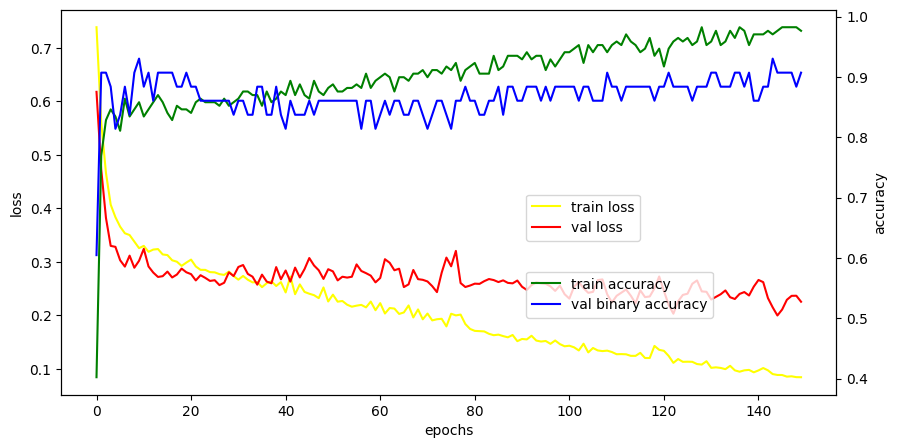

In [317]:
# 모델 학습 과정 확인하기
hist.history.keys() # loss binary_accuracy val_loss val_binary_accuracy
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow',label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red',label='val loss')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc=(0.6,0.4))
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('binary_accuracy'),color='green',label='train accuracy')
acc_ax.plot(hist.history.get('val_binary_accuracy'),color='blue',label='val binary accuracy')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc=(0.6,0.2))

## 6. 모델 평가하기

In [319]:
# 모델 평가하기
loss, accuracy, recall, precision = model.evaluate(X_test,y_test, verbose=1)
# loss = 0.1.2406 , binary_accuracy = 0.0.8132, recall = 0.78, precision = 0.8000
y_hat = (model.predict(X_test)>0.5).reshape(-1).astype(int)

3/3 [==============================] - 0s 9ms/step


## 7. 교차맵

In [322]:
# 교차맵
pd.crosstab(y_test,y_hat,rownames=['실제값'],colnames=['예측값'])

예측값,0,1
실제값,,
0.0,42,8
1.0,9,32


## 8. 모델 저장 및 사용하기

In [202]:
# 모델 저장, 사용하기
save_model(model, 'model/ch07_heart_logistic.h5')

In [267]:
model.predict(X_scaler.transform([X_data[150]])).round()

1/1 [==============================] - 0s 22ms/step


array([[0.]], dtype=float32)

# 분류분석

## 0. 생성된 데이터 전처리 => 분류분석을 위한 원핫인코딩

In [255]:
# 데이터 전처리 : OneHotEncoding
scaled_X_data # X데이터
Y_data = to_categorical(y_data)
Y_data

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.

## 1. 데이터 분할

In [205]:
# 데이터 분할
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(scaled_X_data, Y_data, test_size=0.3)

## 2. 모델 생성 및 구성
- 그래프를 보고 과적합 줄이기 추가

In [237]:
# 모델 생성 및 구성
model2 = Sequential()
model2.add(Input(shape=(13,)))
model2.add(Dense(units=39, activation = 'relu'))
model2.add(Dropout(0.25))
# model2.add(Dense(units=52, activation = 'relu'))
# model2.add(Dense(units=13, activation = 'relu'))
model2.add(Dense(units=2, activation = 'softmax'))
model2.summary()

# model = Sequential()
# model.add(Input(shape=(13,)))
# model.add(Dense(units=39, activation = 'relu'))
# model.add(Dropout(0.2))
# # model.add(Dense(units=13, activation = 'relu'))
# # model.add(Dense(units=13, activation = 'relu'))
# model.add(Dense(units=1, activation = 'sigmoid'))
# model.summary()

Model: "sequential_32"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_101 (Dense)           (None, 39)                546       
                                                                 
 dropout_21 (Dropout)        (None, 39)                0         
                                                                 
 dense_102 (Dense)           (None, 2)                 80        
                                                                 
Total params: 626
Trainable params: 626
Non-trainable params: 0
_________________________________________________________________


## 3. 모델 학습과정 설정

In [238]:
# 모델 학습과정 설정
model2.compile(loss='categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

## 4. 모델 학습

In [240]:
# 모델 학습
hist2 = model2.fit(X_train2,Y_train2,epochs=50,verbose=1, validation_split=0.2)

Epoch 1/50
6/6 [==============================] - 1s 41ms/step - loss: 0.7034 - accuracy: 0.5799 - val_loss: 0.6948 - val_accuracy: 0.5116
Epoch 2/50
6/6 [==============================] - 0s 8ms/step - loss: 0.6672 - accuracy: 0.6036 - val_loss: 0.6522 - val_accuracy: 0.6977
Epoch 3/50
6/6 [==============================] - 0s 10ms/step - loss: 0.6772 - accuracy: 0.5740 - val_loss: 0.6260 - val_accuracy: 0.7209
Epoch 4/50
6/6 [==============================] - 0s 8ms/step - loss: 0.6439 - accuracy: 0.6391 - val_loss: 0.5994 - val_accuracy: 0.7442
Epoch 5/50
6/6 [==============================] - 0s 8ms/step - loss: 0.6497 - accuracy: 0.6746 - val_loss: 0.5782 - val_accuracy: 0.7907
Epoch 6/50
6/6 [==============================] - 0s 7ms/step - loss: 0.6003 - accuracy: 0.7515 - val_loss: 0.5583 - val_accuracy: 0.7907
Epoch 7/50
6/6 [==============================] - 0s 8ms/step - loss: 0.5894 - accuracy: 0.7396 - val_loss: 0.5465 - val_accuracy: 0.7907
Epoch 8/50
6/6 [================

## 5. 모델 학습 과정 확인하기

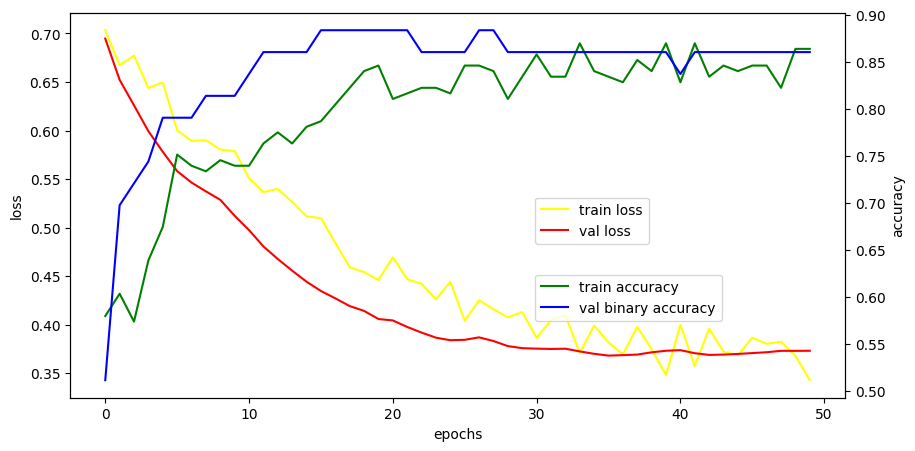

In [300]:
# 모델 학습 과정 확인하기
hist2.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist2.history.get('loss'), color='yellow',label='train loss')
loss_ax.plot(hist2.history.get('val_loss'), color='red',label='val loss')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc=(0.6,0.4))
acc_ax = loss_ax.twinx()
acc_ax.plot(hist2.history.get('accuracy'),color='green',label='train accuracy')
acc_ax.plot(hist2.history.get('val_accuracy'),color='blue',label='val binary accuracy')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc=(0.6,0.2))

## 6. 모델 평가하기

In [245]:
# 모델 평가하기
loss_2, accuracy_2 = model2.evaluate(X_test2,Y_test2,)
loss_2, accuracy_2

3/3 [==============================] - 0s 2ms/step - loss: 0.4147 - accuracy: 0.8242


(0.4147215485572815, 0.8241758346557617)

## 7. 교차맵

In [251]:
# 교차맵
y_hat2 = model2.predict(X_test2).argmax(axis=1)
pd.crosstab(Y_test2.argmax(axis=1),y_hat2,rownames=['실제값'],colnames=['예측값'])

3/3 [==============================] - 0s 2ms/step


예측값,0,1
실제값,,
0,47,5
1,11,28


## 8. 모델 저장 및 사용하기

In [252]:
# 모델 저장 및 사용
save_model(model2,'model/ch07_heart_classification.h5')

In [269]:
model2.predict(X_scaler.transform([X_data[150]])).argmax(axis=1)

1/1 [==============================] - 0s 25ms/step


array([0], dtype=int64)